<a href="https://colab.research.google.com/github/thuphuong0309/XLAA/blob/main/BTL_X%E1%BB%AD_l%C3%BD_%E1%BA%A3nh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NHẬN DẠNG CHỮ VIẾT VÀ HÌNH DẠNG ĐƠN GIẢN

## I. Tiền xử lý

### 1. Bộ dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


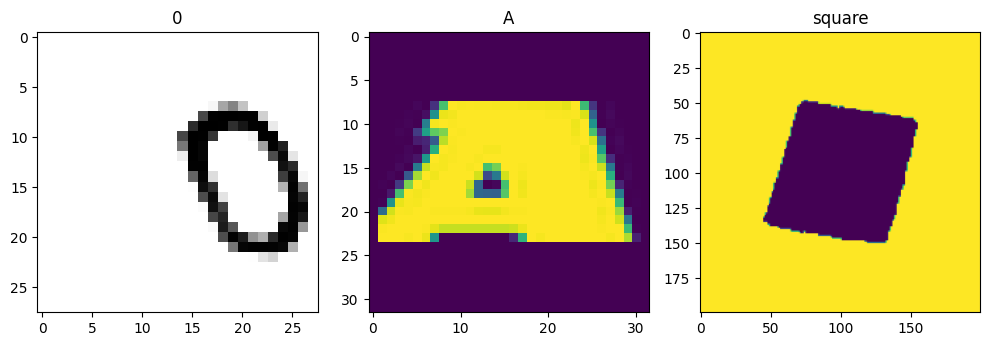

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import os

DATA_DIR = '/content/drive/MyDrive/handwritting'

plt.figure(figsize=(10, 10))

stt=0
for i in os.listdir(DATA_DIR):
    if i == '0' or i=='A' or i=='square':
      for j in os.listdir(os.path.join(DATA_DIR, i)):
        img_path=os.path.join(os.path.join(DATA_DIR, i), j)
        plt.subplot(1,3,stt+1)
        img=plt.imread(img_path)
        plt.imshow(img)
        plt.title(i)
        stt+=1
        break
      if stt==3: break
plt.tight_layout()
plt.show()

In [ ]:
for i in os.listdir(DATA_DIR):
  folder_path=os.path.join(DATA_DIR, i)
  print(f"Số lượng ảnh trong thư mục '{i}': {len(os.listdir(folder_path))}")

Số lượng ảnh trong thư mục '0': 2000
Số lượng ảnh trong thư mục '1': 2000
Số lượng ảnh trong thư mục '2': 2000
Số lượng ảnh trong thư mục '3': 2000
Số lượng ảnh trong thư mục '4': 2000
Số lượng ảnh trong thư mục '5': 2000
Số lượng ảnh trong thư mục '6': 2000
Số lượng ảnh trong thư mục '7': 2000
Số lượng ảnh trong thư mục '8': 2000
Số lượng ảnh trong thư mục '9': 2000
Số lượng ảnh trong thư mục 'A': 2000
Số lượng ảnh trong thư mục 'B': 2000
Số lượng ảnh trong thư mục 'C': 2000
Số lượng ảnh trong thư mục 'D': 2000
Số lượng ảnh trong thư mục 'E': 2000
Số lượng ảnh trong thư mục 'F': 2000
Số lượng ảnh trong thư mục 'G': 2000
Số lượng ảnh trong thư mục 'H': 2000
Số lượng ảnh trong thư mục 'circle': 1999
Số lượng ảnh trong thư mục 'I': 2000
Số lượng ảnh trong thư mục 'J': 2000
Số lượng ảnh trong thư mục 'K': 2000
Số lượng ảnh trong thư mục 'L': 2000
Số lượng ảnh trong thư mục 'M': 2000
Số lượng ảnh trong thư mục 'N': 2000
Số lượng ảnh trong thư mục 'O': 2000
Số lượng ảnh trong thư mục 'P': 2

In [ ]:
for i in ['0','A','square']:
  folder = os.path.join(DATA_DIR,i)
  for j in os.listdir(folder):
    img=plt.imread(os.path.join(folder,j))
    if i=='0': print('Kiểu dữ liệu cho số:', end=' ')
    elif i=='A': print('Kiểu dữ liệu cho chữ', end=' ')
    elif i=='square': print('Kiểu dữ liệu cho hình dạng', end=' ')
    print(img.shape, img.dtype, img.min(), img.max())
    break

Kiểu dữ liệu cho số: (28, 28, 4) float32 0.0 1.0
Kiểu dữ liệu cho chữ (32, 32) float32 0.0 1.0
Kiểu dữ liệu cho hình dạng (200, 200) float32 0.0 1.0


### 2. Tiền xử lý ảnh

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. HÀM CONVOLUTION (Tích chập)
def convolve2d(image, kernel):
    """
    Thực hiện phép tích chập 2D giữa ảnh và kernel.
    Công thức: G(x, y) = sum(kernel * image_window)
    """
    kernel = np.flipud(np.fliplr(kernel)) # Lật kernel
    k_h, k_w = kernel.shape
    img_h, img_w = image.shape

    # Padding (thêm viền 0) để giữ nguyên kích thước ảnh
    pad_h, pad_w = k_h // 2, k_w // 2
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    output = np.zeros_like(image)

    # Duyệt qua từng pixel
    for i in range(img_h):
        for j in range(img_w):
            region = padded_img[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(region * kernel)

    return output

# 2. GAUSSIAN BLUR
def manual_gaussian_blur(image, kernel_size=5, sigma=1.0):
    """
    Tạo bộ lọc Gaussian và tích chập với ảnh.
    Công thức Gaussian: G(x,y) = (1 / (2*pi*sigma^2)) * e^(- (x^2 + y^2) / (2*sigma^2))
    """
    ax = np.linspace(-(kernel_size - 1) / 2., (kernel_size - 1) / 2., kernel_size)
    gauss = np.exp(-0.5 * np.square(ax) / np.square(sigma))
    kernel = np.outer(gauss, gauss)
    kernel = kernel / np.sum(kernel) # Chuẩn hóa để tổng = 1

    return convolve2d(image, kernel)

# --- 3. OTSU THRESHOLDING ---
def manual_otsu_threshold(image, invert=False):
    """
    Thuật toán Otsu tìm ngưỡng T tối ưu để phân tách nền và vật thể.
    """
    # Chuyển về uint8 [0-255] để tính histogram
    img_int = (image * 255).astype(np.uint8) if image.max() <= 1.0 else image.astype(np.uint8)

    # Tính Histogram
    hist, _ = np.histogram(img_int.flatten(), bins=256, range=[0, 256])
    total_pixels = img_int.size

    current_max, threshold = 0, 0
    sum_total = np.dot(np.arange(256), hist)
    sum_bg, weight_bg = 0, 0

    for t in range(256):
        weight_bg += hist[t]
        if weight_bg == 0: continue

        weight_fg = total_pixels - weight_bg
        if weight_fg == 0: break

        sum_bg += t * hist[t]

        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg

        # Between Class Variance = w0 * w1 * (u0 - u1)^2
        var_between = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2

        if var_between > current_max:
            current_max = var_between
            threshold = t

    # Áp dụng ngưỡng
    # Binary: pixel > T ? 255 : 0
    if invert:
        binary_img = np.where(img_int > threshold, 0, 255)
    else:
        binary_img = np.where(img_int > threshold, 255, 0)

    return binary_img.astype(np.uint8)

#  4. RESIZE (Nearest Neighbor)
def manual_resize(image, new_height, new_width):
    """
    Thay đổi kích thước ảnh dùng phương pháp láng giềng gần nhất (Nearest Neighbor Interpolation).
    Công thức: src_x = dst_x * (src_width / dst_width)
    """
    old_height, old_width = image.shape[:2]

    # Tạo lưới tọa độ mới
    row_ratio = old_height / new_height
    col_ratio = old_width / new_width

    # Tính toán tọa độ nguồn tương ứng (làm tròn xuống int)
    new_rows = (np.arange(new_height) * row_ratio).astype(int)
    new_cols = (np.arange(new_width) * col_ratio).astype(int)

    # Map pixels từ ảnh cũ sang ảnh mới
    # Dùng broadcasting của numpy để lấy giá trị nhanh hơn vòng lặp
    resized_img = image[new_rows[:, None], new_cols]

    return resized_img

# 5. XỬ LÝ RGBA (Alpha Blending)
def manual_fix_rgba(img):
    """
    Xử lý ảnh trong suốt thủ công bằng công thức Alpha Blending.
    Pixel = Color * alpha + Background * (1 - alpha)
    """
    if img.ndim != 3 or img.shape[2] != 4:
        return img

    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)

    r, g, b, a = img[:,:,0], img[:,:,1], img[:,:,2], img[:,:,3]
    alpha = a.astype(float) / 255.0
    white = 255

    # Công thức blend với nền trắng
    new_r = (r * alpha + white * (1 - alpha)).astype(np.uint8)
    new_g = (g * alpha + white * (1 - alpha)).astype(np.uint8)
    new_b = (b * alpha + white * (1 - alpha)).astype(np.uint8)

    return np.dstack((new_r, new_g, new_b))

#  6. RGB to Gray
def manual_rgb2gray(img):
    """
    Công thức: Y = 0.299*R + 0.587*G + 0.114*B
    """
    if img.ndim == 2: return img

    return np.dot(img[...,:3], [0.299, 0.587, 0.114])

def process_image_pipeline(img_path, is_digit_folder=False, target_size=(64, 64)):
    # 1. Đọc ảnh bằng matplotlib
    try:
        img = plt.imread(img_path)
    except:
        return None, None

    # Chuẩn hóa về range [0, 255] nếu ảnh là float [0, 1]
    if img.dtype == np.float32 or img.dtype == np.float64:
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)

    # Bước 1: Xử lý nền
    if is_digit_folder and img.shape[2] == 4:
        img_bg_fixed = manual_fix_rgba(img)
    else:
        if img.ndim == 3 and img.shape[2] == 4:
             img_bg_fixed = manual_fix_rgba(img)
        else:
             img_bg_fixed = img.copy()

    # Bước 2: Chuyển xám
    gray = manual_rgb2gray(img_bg_fixed)

    # Bước 3: Gaussian Blur
    blur = manual_gaussian_blur(gray, kernel_size=5, sigma=1.0)

    # Bước 4: Otsu Threshold
    # Tính trung bình để quyết định đảo màu
    mean_val = np.mean(blur)

    should_invert = is_digit_folder or (mean_val > 127)

    binary = manual_otsu_threshold(blur, invert=should_invert)

    #  Bước 5: Resize
    resized = manual_resize(binary, target_size[0], target_size[1])

    # Bước 6: Chuẩn hóa & Thêm chiều
    final = resized.astype("float32") / 255.0
    final = np.expand_dims(final, axis=-1)

    intermediates = {
        'original': img,
        'bg_fixed': img_bg_fixed,
        'gray': gray,
        'blur': blur,
        'binary': binary,
        'resized': resized
    }

    return final, intermediates

--- MINH HỌA QUY TRÌNH TIỀN XỬ LÝ ---


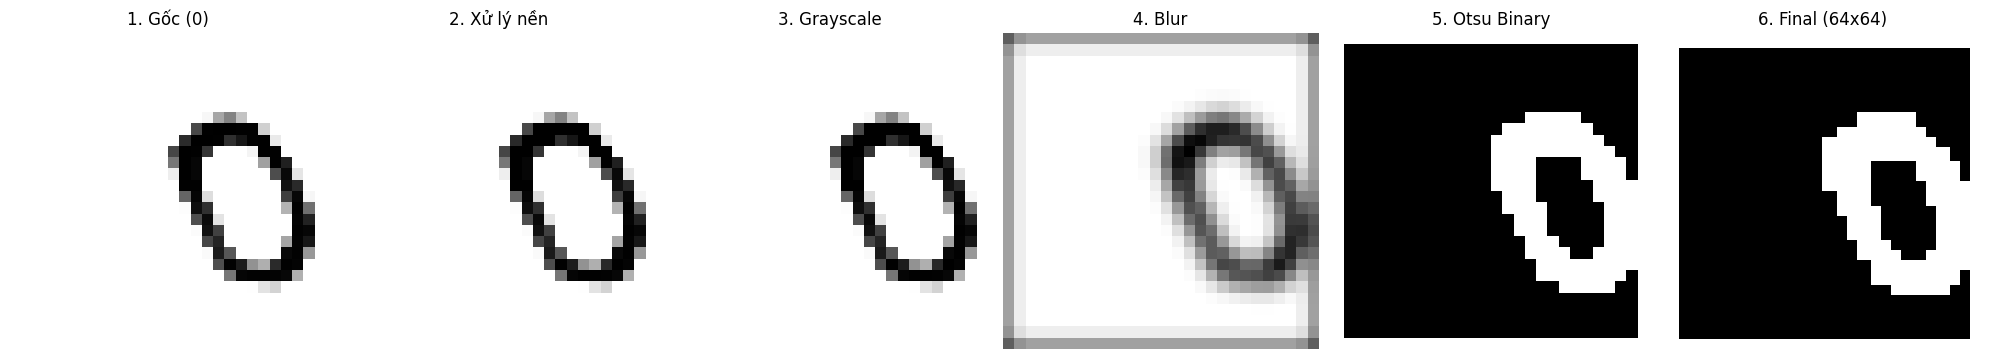

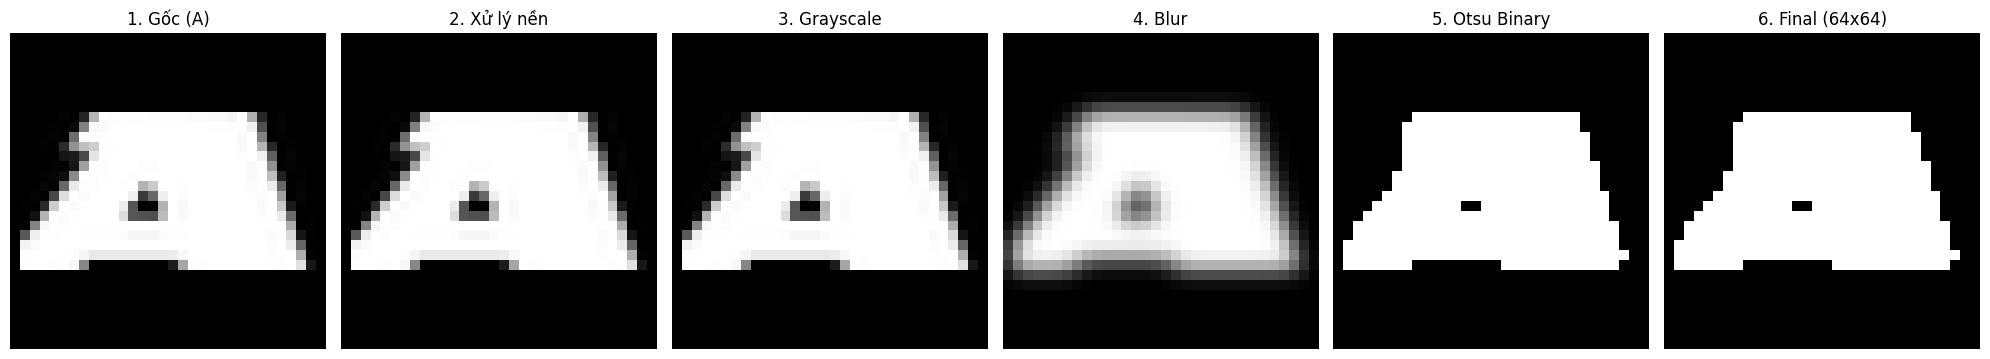

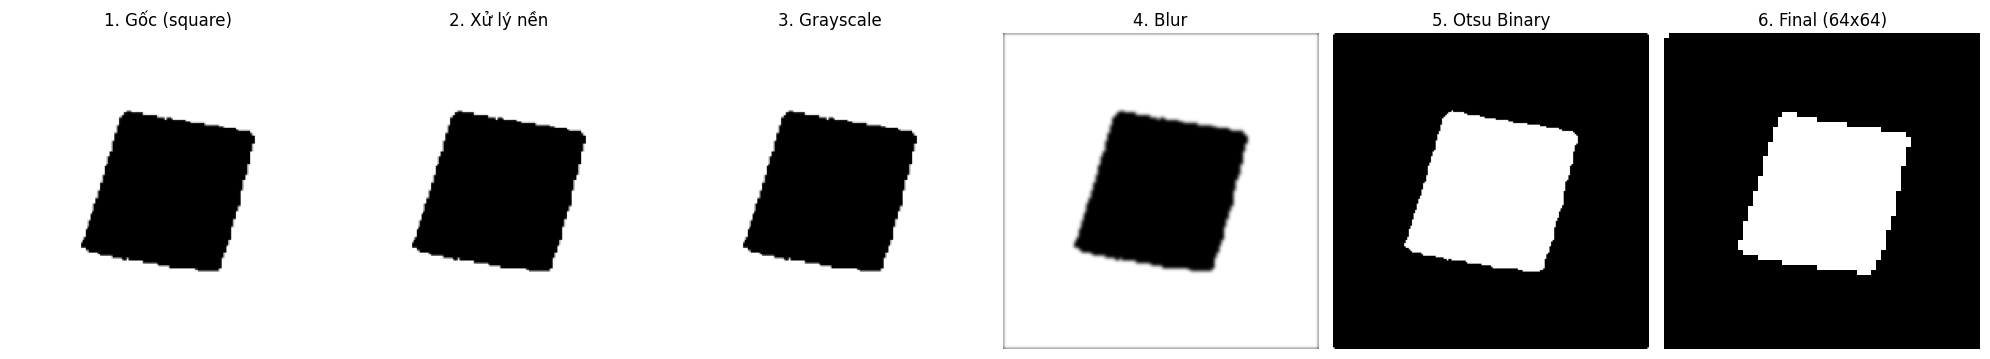

In [ ]:
def visualize_pipeline(img_path, label_name):
    is_digit = label_name.isdigit()

    _, stages = process_image_pipeline(img_path, is_digit_folder=is_digit)

    if stages is None:
        print(f"Lỗi đọc ảnh: {img_path}")
        return

    fig, axes = plt.subplots(1, 6, figsize=(20, 4))

    # 1. Gốc
    if stages['original'].ndim == 3 and stages['original'].shape[2] == 4:
         axes[0].imshow(cv2.cvtColor(stages['original'], cv2.COLOR_BGRA2RGBA))
    elif stages['original'].ndim == 3:
         axes[0].imshow(cv2.cvtColor(stages['original'], cv2.COLOR_BGR2RGB))
    else:
        axes[0].imshow(stages['original'], cmap='gray')
    axes[0].set_title(f"1. Gốc ({label_name})")

    # 2. Nền
    if stages['bg_fixed'].ndim == 3:
        axes[1].imshow(stages['bg_fixed']) # Đã là RGB từ hàm xử lý
    else:
        axes[1].imshow(stages['bg_fixed'], cmap='gray')
    axes[1].set_title("2. Xử lý nền")

    # 3. Grayscale
    axes[2].imshow(stages['gray'], cmap='gray')
    axes[2].set_title("3. Grayscale")

    # 4. Blur
    axes[3].imshow(stages['blur'], cmap='gray')
    axes[3].set_title("4. Blur")

    # 5. Binary
    axes[4].imshow(stages['binary'], cmap='gray')
    axes[4].set_title("5. Otsu Binary")

    # 6. Final
    axes[5].imshow(stages['resized'], cmap='gray')
    axes[5].set_title("6. Final (64x64)")

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

DATA_DIR = '/content/drive/MyDrive/handwritting'
test_folders = ['0', 'A', 'square']

print("--- MINH HỌA QUY TRÌNH TIỀN XỬ LÝ ---")
for folder_name in test_folders:
    folder_path = os.path.join(DATA_DIR, folder_name)
    if os.path.exists(folder_path):
        img_name = os.listdir(folder_path)[0]
        img_path = os.path.join(folder_path, img_name)
        visualize_pipeline(img_path, folder_name)

In [ ]:
import os
import numpy as np

images = []
labels = []
output = []

folder_list = sorted(os.listdir(DATA_DIR))

print("Bắt đầu xử lý...")

for stt, i in enumerate(folder_list):
    folder_path = os.path.join(DATA_DIR, i)

    if not os.path.isdir(folder_path):
        continue

    output.append(i)

    so = False
    if i.isdigit():
        so = True

    print(f"Đang xử lý lớp: {i} (Là số: {so})")

    for j in os.listdir(folder_path):
        img_path = os.path.join(folder_path, j)

        try:
            img, _ = process_image_pipeline(img_path, is_digit_folder=so)

            if img is not None:
                images.append(img)
                labels.append(stt)
        except Exception as e:
            print(f"Lỗi ảnh {j}: {e}")

images = np.array(images)
labels = np.array(labels)

print(f"Kích thước images: {images.shape}")
print(f"Kích thước labels: {labels.shape}")
print(f"Danh sách lớp: {output}")

Bắt đầu xử lý...
Đang xử lý lớp: 0 (Là số: True)
Đang xử lý lớp: 1 (Là số: True)
Đang xử lý lớp: 2 (Là số: True)
Đang xử lý lớp: 3 (Là số: True)
Đang xử lý lớp: 4 (Là số: True)
Đang xử lý lớp: 5 (Là số: True)
Đang xử lý lớp: 6 (Là số: True)
Đang xử lý lớp: 7 (Là số: True)
Đang xử lý lớp: 8 (Là số: True)
Đang xử lý lớp: 9 (Là số: True)
Đang xử lý lớp: A (Là số: False)
Đang xử lý lớp: B (Là số: False)
Đang xử lý lớp: C (Là số: False)
Đang xử lý lớp: D (Là số: False)
Đang xử lý lớp: E (Là số: False)
Đang xử lý lớp: F (Là số: False)
Đang xử lý lớp: G (Là số: False)
Đang xử lý lớp: H (Là số: False)
Đang xử lý lớp: I (Là số: False)
Đang xử lý lớp: J (Là số: False)
Đang xử lý lớp: K (Là số: False)
Đang xử lý lớp: L (Là số: False)
Đang xử lý lớp: M (Là số: False)
Đang xử lý lớp: N (Là số: False)
Đang xử lý lớp: O (Là số: False)
Đang xử lý lớp: P (Là số: False)
Đang xử lý lớp: Q (Là số: False)
Đang xử lý lớp: R (Là số: False)
Đang xử lý lớp: S (Là số: False)
Đang xử lý lớp: T (Là số: False)
Đan

In [ ]:
# Danh sách các đầu ra
print(output)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'circle', 'square', 'triangle']


In [ ]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu từ 'images' và 'labels' thành các tập train/test
X_train, X_test, y_train, y_test = train_test_split(
    images, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"Kích thước tập huấn luyện (X_train): {X_train.shape}")
print(f"Kích thước tập kiểm tra (X_test): {X_test.shape}")

Kích thước tập huấn luyện (X_train): (62397, 64, 64, 1)
Kích thước tập kiểm tra (X_test): (15600, 64, 64, 1)


## II. Xây dựng mô hình huấn luyện

### 1. Xây dựng kiến trúc mô hình

In [ ]:
from tensorflow import keras
from keras import layers

inputs = keras.Input(shape=(64, 64, 1))

# Block 1
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.2)(x)

# Block 2
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.25)(x)

# Block 3
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.3)(x)

# Block 4
x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.35)(x)

# Block 5
x = layers.Conv2D(512, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(512, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(512, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.4)(x)

# Fully Connected
x = layers.Flatten()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(39, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,042,567 (34.49 MB)

 Trainable params: 9,035,015 (34.47 MB)

 Non-trainable params: 7,552 (29.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2, callbacks=[early, reduce_lr])

Epoch 1/25
1564/1564 ━━━━━━━━━━━━━━━━━━━━ 112s 52ms/step - accuracy: 0.3402 - loss: 2.4824 - val_accuracy: 0.8281 - val_loss: 0.6546 - learning_rate: 0.0010
Epoch 2/25
1564/1564 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.8038 - loss: 0.7654 - val_accuracy: 0.8574 - val_loss: 0.5418 - learning_rate: 0.0010
Epoch 3/25
1564/1564 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.8367 - loss: 0.6362 - val_accuracy: 0.8740 - val_loss: 0.4752 - learning_rate: 0.0010
Epoch 4/25
1564/1564 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.8519 - loss: 0.5768 - val_accuracy: 0.8733 - val_loss: 0.4817 - learning_rate: 0.0010
Epoch 5/25
1564/1564 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.8642 - loss: 0.5300 - val_accuracy: 0.8844 - val_loss: 0.4343 - learning_rate: 0.0010
Epoch 6/25
1564/1564 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.8760 - loss: 0.4843 - val_accuracy: 0.8923 - val_loss: 0.4100 - learning_rate: 0.0010
Epoch 7/25
1564/1564 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accur

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

===== Layer: conv2d | Output shape: (1, 64, 64, 32) =====


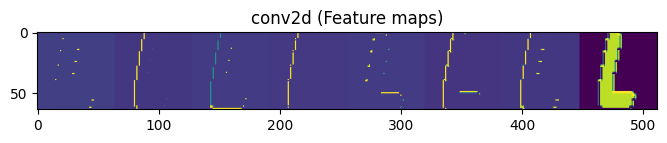


===== Layer: conv2d_1 | Output shape: (1, 64, 64, 32) =====


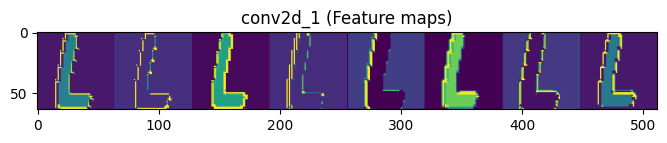


===== Layer: max_pooling2d | Output shape: (1, 32, 32, 32) =====


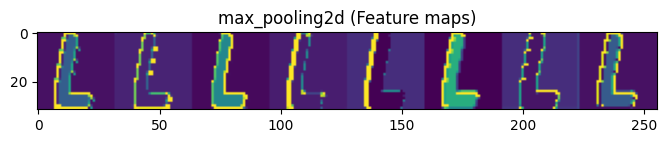


===== Layer: conv2d_2 | Output shape: (1, 32, 32, 64) =====


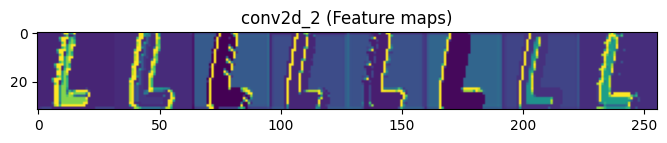


===== Layer: conv2d_3 | Output shape: (1, 32, 32, 64) =====


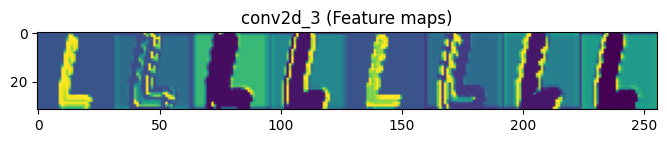


===== Layer: max_pooling2d_1 | Output shape: (1, 16, 16, 64) =====


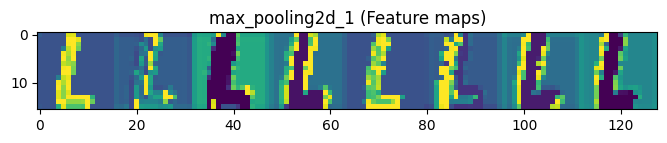


===== Layer: conv2d_4 | Output shape: (1, 16, 16, 128) =====


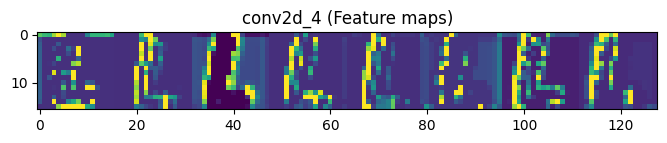


===== Layer: conv2d_5 | Output shape: (1, 16, 16, 128) =====


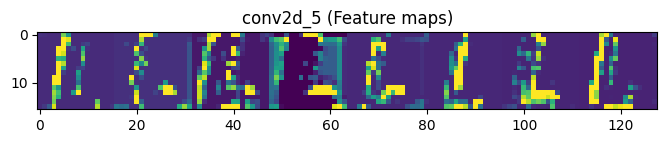


===== Layer: conv2d_6 | Output shape: (1, 16, 16, 128) =====


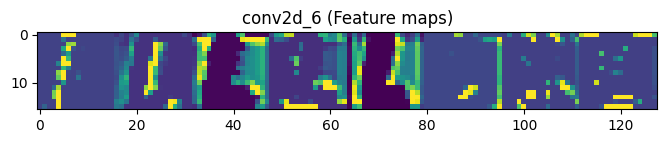


===== Layer: max_pooling2d_2 | Output shape: (1, 8, 8, 128) =====


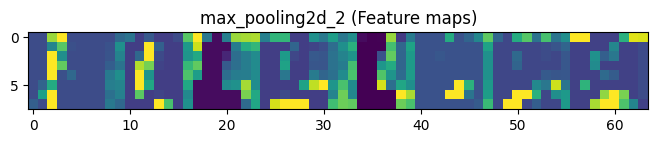


===== Layer: conv2d_7 | Output shape: (1, 8, 8, 256) =====


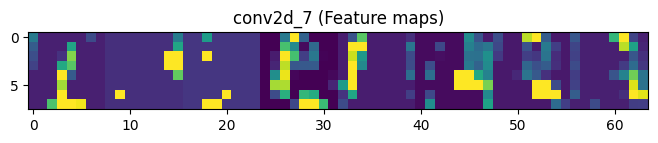


===== Layer: conv2d_8 | Output shape: (1, 8, 8, 256) =====


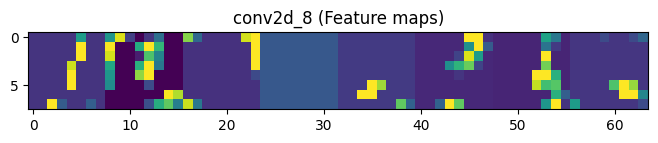


===== Layer: conv2d_9 | Output shape: (1, 8, 8, 256) =====


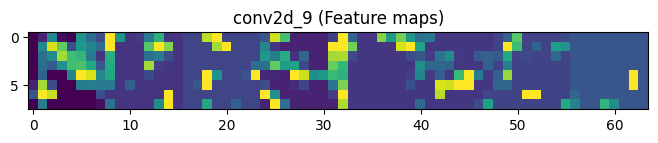


===== Layer: max_pooling2d_3 | Output shape: (1, 4, 4, 256) =====


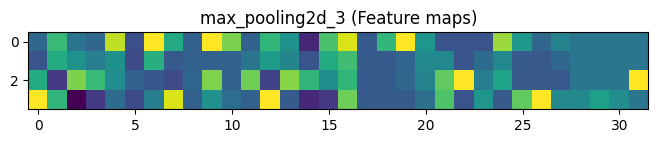


===== Layer: conv2d_10 | Output shape: (1, 4, 4, 512) =====


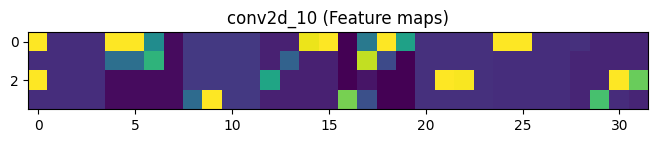


===== Layer: conv2d_11 | Output shape: (1, 4, 4, 512) =====


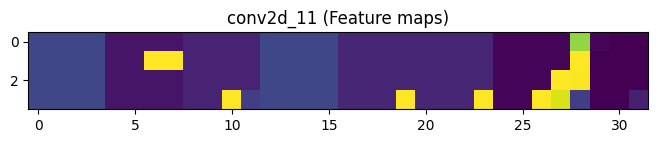


===== Layer: conv2d_12 | Output shape: (1, 4, 4, 512) =====


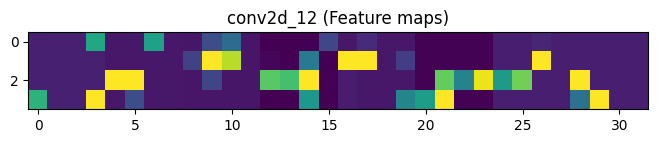


===== Layer: max_pooling2d_4 | Output shape: (1, 2, 2, 512) =====


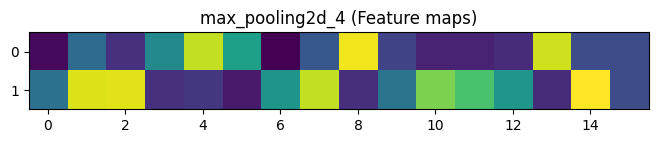


===== Layer: flatten | Output shape: (1, 2048) =====


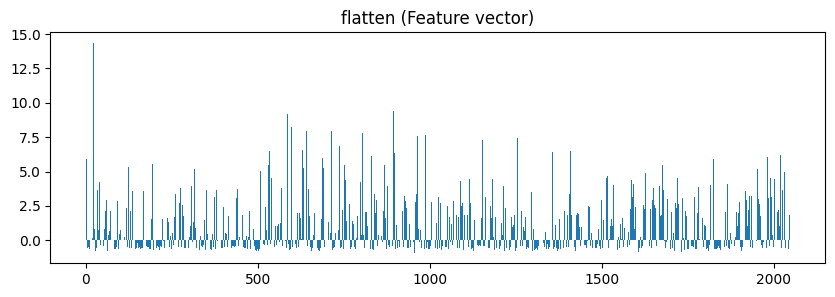


===== Layer: dense | Output shape: (1, 512) =====


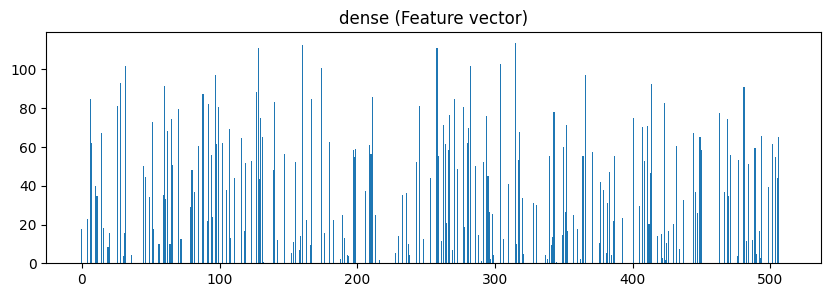


===== Layer: dense_1 | Output shape: (1, 256) =====


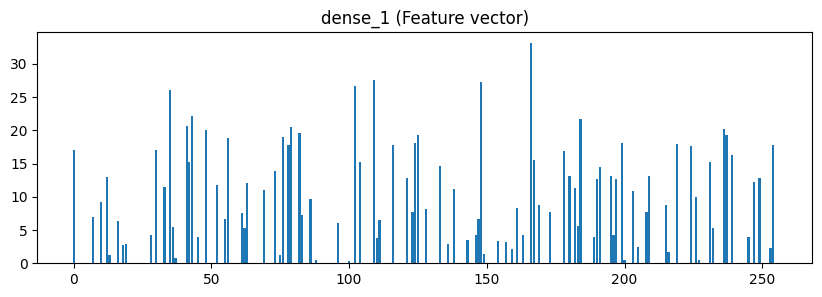


===== Layer: dense_2 | Output shape: (1, 128) =====


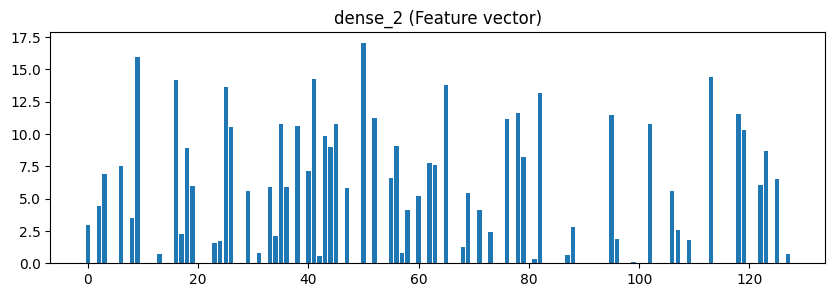


===== Layer: dense_3 | Output shape: (1, 39) =====


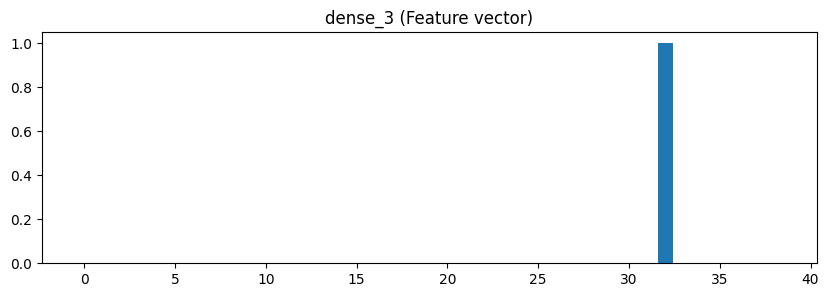

In [ ]:
# Hình ảnh sau khi đi qua các layers trong model
layer_names = [layer.name for layer in model.layers
               if any(k in layer.name for k in ['conv', 'pool', 'flatten', 'dense'])]
layer_outputs = [layer.output for layer in model.layers
                 if any(k in layer.name for k in ['conv', 'pool', 'flatten', 'dense'])]

activation_model = keras.Model(inputs=model.input, outputs=layer_outputs)

sample_img = X_train[1000:1001]

activations = activation_model.predict(sample_img)

for layer_name, layer_activation in zip(layer_names, activations):
    print(f"\n===== Layer: {layer_name} | Output shape: {layer_activation.shape} =====")

    if len(layer_activation.shape) == 4:
        n_features = layer_activation.shape[-1]
        size = layer_activation.shape[1]
        n_cols = min(8, n_features)
        display_grid = np.zeros((size, size * n_cols))

        for i in range(n_cols):
            x = layer_activation[0, :, :, i]
            x -= x.mean()
            x /= (x.std() + 1e-5)
            x *= 64
            x += 128
            x = np.clip(x, 0, 255).astype('uint8')
            display_grid[:, i * size:(i + 1) * size] = x

        scale = 1. / size
        plt.figure(figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0]))
        plt.title(f"{layer_name} (Feature maps)")
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')
        plt.show()

    elif len(layer_activation.shape) == 2:
        plt.figure(figsize=(10, 3))
        plt.title(f"{layer_name} (Feature vector)")
        plt.bar(range(layer_activation.shape[-1]), layer_activation[0])
        plt.show()

### 2. Đánh giá mô hình

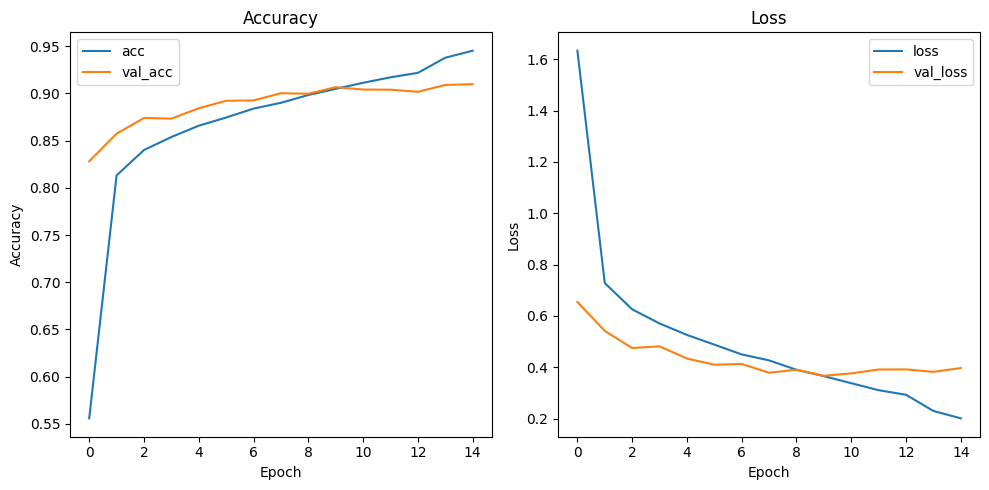

In [ ]:
epochs = range(len(history.history['accuracy']))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(epochs, history.history['accuracy'], label='acc')
plt.plot(epochs, history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs, history.history['loss'], label='loss')
plt.plot(epochs, history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Sử dụng X_test và y_test
y_pred=model.predict(X_test)
y_pred=np.argmax(y_pred,axis=1)

acc=accuracy_score(y_test,y_pred)
recall=recall_score(y_test,y_pred,average='macro')
precision=precision_score(y_test,y_pred,average='macro')
f1=f1_score(y_test,y_pred,average='macro')
print('acc =', acc)
print('recall =', recall)
print('precision =', precision)
print('f1 =', f1)

489/489 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step
acc = 0.89923273657289
recall = 0.8993200382433864
precision = 0.9055190528416256
f1 = 0.9006992724969385


In [ ]:
model_filename_h5 = "content/drive/handwritting/model1.h5"

model.save(model_filename_h5)

print(f"Đã lưu model vào file: {model_filename_h5}")

Đã lưu model vào file: content/drive/handwritting/model_xla.h5


## III. Sản phẩm demo